<h1 style="text-align: center;">Waste Sorting Using Computer Vision using MobileNet</h1>


![waste%202.png](attachment:waste%202.png)

# 1. Problem Statement

Imagine if every piece of trash in the world could automatically find the right bin to go to! That’s the magic of computer vision with waste sorting. Sorting waste is essential for keeping our planet clean. When we sort waste correctly:

    Recyclables (like plastic bottles and cans) can be reused, which saves resources.
    Organic waste can be composted, helping plants grow.
    Non-recyclables go to landfills, but it’s better if we minimize them.


By training a computer to recognize waste, we can speed up sorting and reduce mistakes, helping the environment and recycling process.

# 2. Objectives

In this project, we will:

    Use computer vision to help identify types of waste.
    Train a model called MobileNet to "see" and categorize images as Organic (O) or Recyclable (R).
    Use a dataset of waste images, practice sorting them, and observe how the computer learns to differentiate between them.

# 3. Dataset Information

Our dataset contains images of waste items that belong to two categories:

    O (Organic): For food scraps, leaves, or other natural waste.
    R (Recyclable): For plastics, metals, and items that can be reused.

This dataset is organized into two folders:

    Train Folder: Where images are used to teach the computer what each type of waste looks like.
    Test Folder: To check if the computer has learned to sort images correctly.

Download Dataset Manually from Kaggle Website

    Go to the Kaggle website, navigate to the dataset you want (e.g., the "Waste Classification Data").
    URL for dataset used in this project : https://www.kaggle.com/datasets/techsash/waste-classification-data
    Click the URL and click Download to manually download the dataset as a ZIP file.
    Once downloaded, unzip the file and place it in your working directory.

# 4. Understanding MobileNet

Think of MobileNet as a quick learner that’s lightweight and fast. MobileNet is designed for mobile devices, making it perfect for applications where we don’t have a lot of computing power, like on phones or tablets. It can recognize objects by extracting features from images and comparing them to what it has learned.

    Lightweight: Works on mobile devices and runs fast.
    Good Accuracy: Efficiently identifies objects, like if an item is recyclable or organic.
    Feature Extraction: Takes essential details from images (like shapes and colors).

# 5. Code Implementation

Let’s walk through the code to see how we train MobileNet to sort waste images.

#### Import Libraries and Prepare Dataset

In [1]:
pip install opendatasets

In [2]:
import opendatasets as od

od.download(
    "https://www.kaggle.com/datasets/techsash/waste-classification-data")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: kailasdoke07
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/techsash/waste-classification-data


100%|██████████| 427M/427M [00:05<00:00, 87.1MB/s]


Found 22564 images belonging to 2 classes.
Found 2513 images belonging to 2 classes.


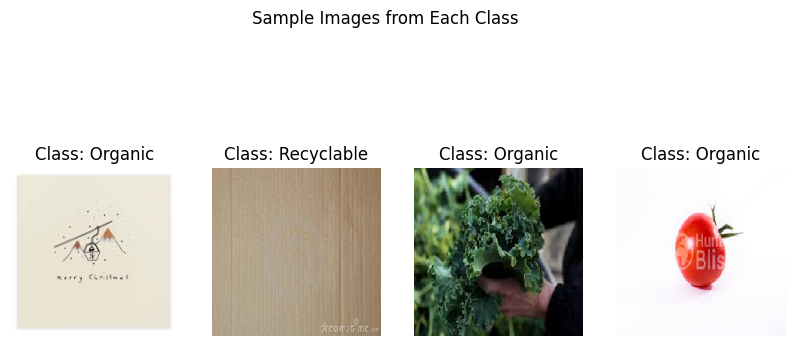

In [3]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os

#
# base_dir = r"/content/waste-classification-data/DATASET/"
# train_dir = base_dir + r"\TRAIN"
# test_dir = base_dir + r"\TEST"

# Set up paths to the train and test directories

base_dir = "/content/waste-classification-data/DATASET" # Remove the trailing /
train_dir = os.path.join(base_dir, "TRAIN") # Use os.path.join for platform independence
test_dir = os.path.join(base_dir, "TEST") # Use os.path.join for platform independence

# Use ImageDataGenerator to prepare the data for training and testing
train_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary'
)

test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary'
)
# Display sample images from each clas
plt.figure(figsize=(10, 5))
for i, (image, label) in enumerate(train_data):  # Use enumerate and __next__ implicitly
    if i >= 4:  # Limit to 4 images
        break
    plt.subplot(1, 4, i + 1)
    plt.imshow(image[0])
    plt.title("Class: " + ("Organic" if label[0] == 0 else "Recyclable"))
    plt.axis('off')
plt.suptitle("Sample Images from Each Class")
plt.show()



# Here, we are resizing images to 224x224 pixels, standard for MobileNet, and labeling them as binary (O or R).
# Also displaying the datasets


#### Load and Configure MobileNet Model

In [4]:
mobilenet_model = tf.keras.applications.MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights='imagenet')
mobilenet_model.trainable = False  # Freeze base model layers

# Add custom layers for classification
model = tf.keras.Sequential([
    mobilenet_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# We start with a pre-trained MobileNet model, adding layers to classify waste images into O or R.


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


#### Train the Model

In [ ]:
history = model.fit(
    train_data,
    validation_data=test_data,
    epochs=10
)

# After training the model, save it to a file
model.save('mobilenet_waste_classifier.h5')

loss, accuracy = model.evaluate(test_data)
print("Model Accuracy:", accuracy)

# The model learns over 5 epochs, seeing images in the training data, adjusting itself, and testing on new images.

Epoch 1/10
706/706 ━━━━━━━━━━━━━━━━━━━━ 82s 89ms/step - accuracy: 0.9076 - loss: 0.2294 - val_accuracy: 0.8747 - val_loss: 0.2883
Epoch 2/10
706/706 ━━━━━━━━━━━━━━━━━━━━ 39s 49ms/step - accuracy: 0.9348 - loss: 0.1711 - val_accuracy: 0.9005 - val_loss: 0.2383
Epoch 3/10
706/706 ━━━━━━━━━━━━━━━━━━━━ 34s 48ms/step - accuracy: 0.9406 - loss: 0.1572 - val_accuracy: 0.8930 - val_loss: 0.2593
Epoch 4/10
706/706 ━━━━━━━━━━━━━━━━━━━━ 41s 49ms/step - accuracy: 0.9432 - loss: 0.1495 - val_accuracy: 0.9001 - val_loss: 0.2442
Epoch 5/10
706/706 ━━━━━━━━━━━━━━━━━━━━ 41s 58ms/step - accuracy: 0.9450 - loss: 0.1454 - val_accuracy: 0.8949 - val_loss: 0.2619
Epoch 6/10
706/706 ━━━━━━━━━━━━━━━━━━━━ 35s 50ms/step - accuracy: 0.9471 - loss: 0.1423 - val_accuracy: 0.8918 - val_loss: 0.2646
Epoch 7/10
706/706 ━━━━━━━━━━━━━━━━━━━━ 37s 52ms/step - accuracy: 0.9483 - loss: 0.1392 - val_accuracy: 0.8754 - val_loss: 0.3029
Epoch 8/10
706/706 ━━━━━━━━━━━━━━━━━━━━ 33s 47ms/step - accuracy: 0.9478 - loss: 0.1383 - 

79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - accuracy: 0.8834 - loss: 0.2903
Model Accuracy: 0.8834062814712524


#### Evaluate the Model

In [ ]:

from sklearn.metrics import classification_report, confusion_matrix

# Generate predictions
y_pred_prob = model.predict(test_data).flatten()
y_pred = (y_pred_prob > 0.5).astype(int)  # Convert probabilities to binary predictions
y_true = test_data.classes  # True labels from test data

# Print classification report
print("Classification Report:\n", classification_report(y_true, y_pred, target_names=['Organic', 'Recyclable']))

# Print confusion matrix
conf_matrix = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:\n", conf_matrix)


# Here, we measure the performance of the model.

79/79 ━━━━━━━━━━━━━━━━━━━━ 12s 101ms/step
Classification Report:
               precision    recall  f1-score   support

     Organic       0.55      0.62      0.58      1401
  Recyclable       0.43      0.35      0.39      1112

    accuracy                           0.50      2513
   macro avg       0.49      0.49      0.49      2513
weighted avg       0.50      0.50      0.50      2513

Confusion Matrix:
 [[873 528]
 [718 394]]


# 6. Testing the model



1/1 ━━━━━━━━━━━━━━━━━━━━ 10s 10s/step


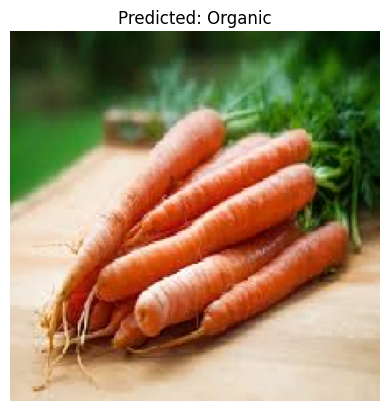

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import load_img, img_to_array

# Load model and image
model = tf.keras.models.load_model('mobilenet_waste_classifier.h5')
img = load_img("/content/waste-classification-data/DATASET/TEST/O/O_12576.jpg", target_size=(224, 224))

# Preprocess and predict
img_array = np.expand_dims(img_to_array(img) / 255.0, axis=0)
pred = model.predict(img_array)[0][0]
label = 'Organic' if pred < 0.5 else 'Non Organic'

# Display result
plt.imshow(img)
plt.title(f"Predicted: {label}")
plt.axis('off')
plt.show()


# 7. Conclusion

By learning to identify waste, MobileNet becomes a helpful tool in sorting. This project highlights how computer vision can make real-life processes like waste sorting easier and faster. Using this setup, we can eventually create applications for recycling plants or even home use, contributing to a cleaner and more sustainable world.